In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
import keras
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
path = r"U:\Fruits_New"
cate = ['freshapples' , "freshbanana" ,'freshpomegranate', 'freshwatermelon' ,'freshmango' , "freshoranges" ,
        "rottenapples" ,'rottenmango', 'rottenpomegranate', "rottenbanana" ,'rottenwatermelon' , "rottenoranges",
       'InavalidImage']

In [3]:
image_size = 224
input_image = []
for i in cate :
    folders = os.path.join(path , i )
    labels = cate.index(i)
    for image in os.listdir(folders):
        image_path = os.path.join (folders , image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize (image_array, (image_size , image_size))
        input_image.append ([image_array,labels])

In [4]:
len(input_image)

14329

In [5]:
input_image[9000]

[array([[[129, 149, 167],
         [113, 133, 149],
         [ 70,  90, 100],
         ...,
         [ 74, 182, 191],
         [ 74, 187, 194],
         [ 37, 154, 159]],
 
        [[129, 149, 167],
         [114, 134, 149],
         [ 70,  91, 100],
         ...,
         [ 73, 181, 190],
         [ 74, 187, 194],
         [ 38, 155, 160]],
 
        [[130, 149, 167],
         [114, 134, 150],
         [ 71,  91, 101],
         ...,
         [ 73, 181, 189],
         [ 74, 187, 194],
         [ 39, 156, 161]],
 
        ...,
 
        [[147, 152, 153],
         [140, 145, 146],
         [123, 128, 129],
         ...,
         [253, 255, 254],
         [251, 254, 252],
         [250, 253, 251]],
 
        [[192, 197, 198],
         [195, 200, 200],
         [197, 202, 203],
         ...,
         [253, 255, 254],
         [253, 255, 254],
         [253, 255, 254]],
 
        [[239, 244, 245],
         [241, 246, 247],
         [244, 249, 250],
         ...,
         [253, 255, 254],
  

In [6]:
np.random.shuffle(input_image)

In [7]:
input_image_train  = input_image[0: 11463]
input_image_test   = input_image[11463: 14329]

In [8]:
X_train =[]
Y_train = []

for X_values , labels in  input_image_train :
    img_rgb = cv2.cvtColor(X_values, cv2.COLOR_BGR2RGB)
    X_train.append(img_rgb)
    Y_train.append(labels)

In [9]:
X_test =[]
Y_test = []

for X_values , labels in  input_image_test :
    img_rgb = cv2.cvtColor(X_values, cv2.COLOR_BGR2RGB)
    X_test.append(img_rgb)
    Y_test.append(labels)

In [10]:
X_train= np.array(X_train)
Y_train= np.array(Y_train)
X_test= np.array(X_test)
Y_test = np.array (Y_test)

In [11]:
X_train  = X_train/ 255

In [12]:
X_test  = X_test/ 255 

In [13]:
len(X_train)

11463

In [14]:
len(X_test)

2866

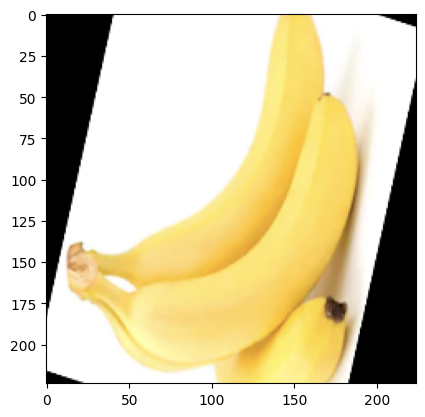

In [16]:
plt.imshow(X_train[951])

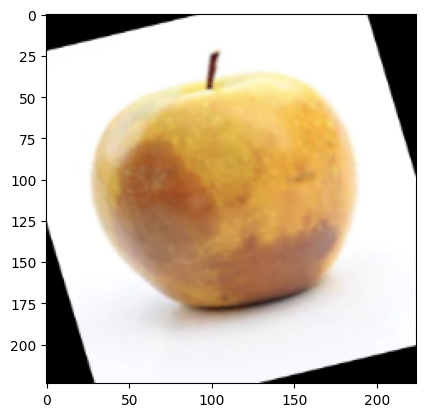

In [20]:
plt.imshow(X_test[1400])

In [21]:
model = Sequential()

# Block 1
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(image_size, image_size, 3)))
model.add(MaxPool2D(pool_size=(2,2)))
    
# Block 2
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Block 3
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2)))

# Classifier
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))       # prevents overfitting
model.add(Dense(128, activation='relu'))
model.add(Dense(13, activation='softmax'))

C:\Users\Udit Gupta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer= adam, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping( monitor='val_accuracy', patience=2, restore_best_weights=True )
history = model.fit( X_train, Y_train, epochs=10, validation_split=0.2, batch_size=32, callbacks=[early_stop])

Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 499s 2s/step - accuracy: 0.4979 - loss: 1.4649 - val_accuracy: 0.7815 - val_loss: 0.6535
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 248s 863ms/step - accuracy: 0.8052 - loss: 0.5861 - val_accuracy: 0.8661 - val_loss: 0.3849
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 259s 855ms/step - accuracy: 0.8711 - loss: 0.3896 - val_accuracy: 0.8901 - val_loss: 0.3136
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 279s 914ms/step - accuracy: 0.9052 - loss: 0.2828 - val_accuracy: 0.9137 - val_loss: 0.2480
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 341s 981ms/step - accuracy: 0.9176 - loss: 0.2405 - val_accuracy: 0.9376 - val_loss: 0.1743
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 260s 907ms/step - accuracy: 0.9350 - loss: 0.1883 - val_accuracy: 0.9337 - val_loss: 0.1973
Epoch 7/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 241s 838ms/step - accuracy: 0.9420 - loss: 0.1727 - val_accuracy: 0.9459 - val_loss: 0.1805
Epoch 8/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 261s 835ms/step - accuracy: 0.9497 - lo

In [23]:
from sklearn.metrics import confusion_matrix , classification_report

In [24]:
pred=model.predict(X_test)

pred_cat=pred.argmax(axis=1)

90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step


In [25]:
tab = confusion_matrix(Y_test,pred.argmax(axis=1))
tab

array([[253,   0,   3,   1,   1,   2,   7,   0,   0,   0,   0,   1,   0],
       [  0, 239,   0,   0,   0,   0,   1,   2,   0,   2,   0,   1,   2],
       [  1,   0, 221,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   2, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   1,   0,   0, 213,   0,   0,   1,   0,   0,   0,   0,   0],
       [  6,   0,   0,   0,   1, 242,   2,   0,   0,   0,   0,  12,   0],
       [ 18,   0,   0,   0,   0,   6, 165,   2,   1,   3,   0,  18,   0],
       [  0,   0,   0,   0,   0,   0,   0, 197,   0,   1,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 210,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   6,   0, 225,   1,   0,   2],
       [  0,   0,   0,   0,   1,   0,   0,   3,   0,   1, 192,   1,   0],
       [  0,   0,   0,   0,   0,   9,   8,   1,   2,   4,   0, 200,   1],
       [  0,   0,   0,   0,   1,   0,   0,   3,   1,   5,   0,   0, 194]])

In [26]:
print(classification_report(Y_test,pred_cat))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93       268
           1       1.00      0.97      0.98       247
           2       0.98      0.99      0.98       223
           3       0.99      0.99      0.99       168
           4       0.98      0.99      0.99       215
           5       0.93      0.92      0.93       263
           6       0.90      0.77      0.83       213
           7       0.92      0.99      0.95       198
           8       0.98      1.00      0.99       210
           9       0.93      0.96      0.95       234
          10       0.99      0.97      0.98       198
          11       0.86      0.89      0.87       225
          12       0.97      0.95      0.96       204

    accuracy                           0.95      2866
   macro avg       0.95      0.95      0.95      2866
weighted avg       0.95      0.95      0.95      2866



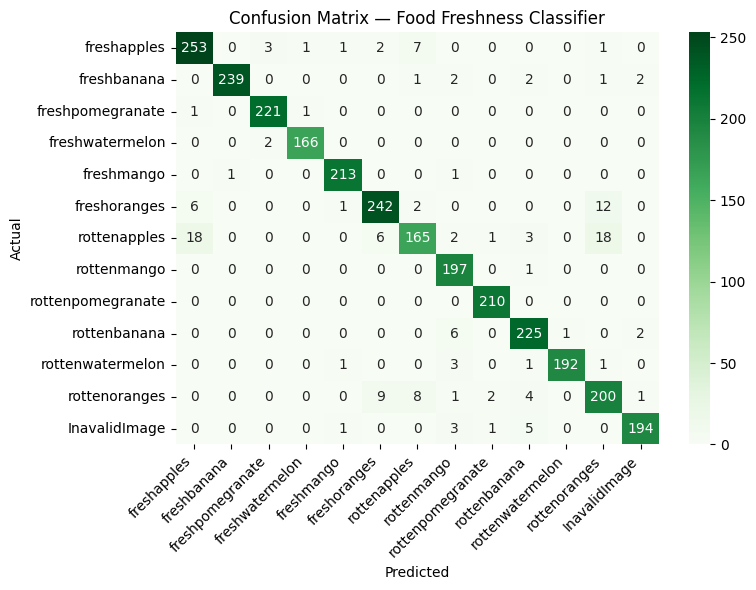

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(tab, annot = True, fmt = 'd', xticklabels = cate ,yticklabels = cate, cmap = 'Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Food Freshness Classifier')
plt.xticks(rotation = 45, ha ='right')
plt.tight_layout()
plt.show()

In [28]:
model.save('food_freshness_or_rotten_model.keras')
print("Model saved!")

Model saved!


In [29]:
model.save('food_freshness_or_rotten_model.h5')
print("Model saved!")

Model saved!


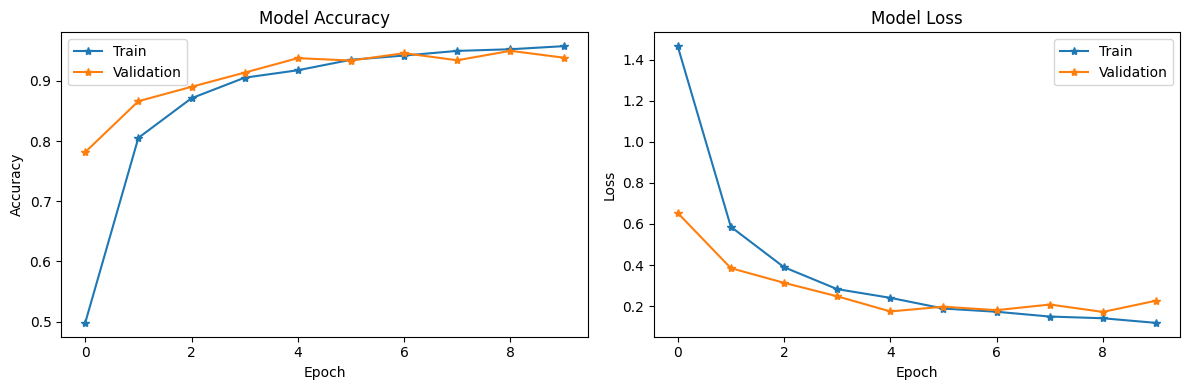

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label = 'Train', marker = '*')
axes[0].plot(history.history['val_accuracy'], label = 'Validation', marker = '*')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label = 'Train', marker = '*')
axes[1].plot(history.history['val_loss'], label = 'Validation', marker = '*')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

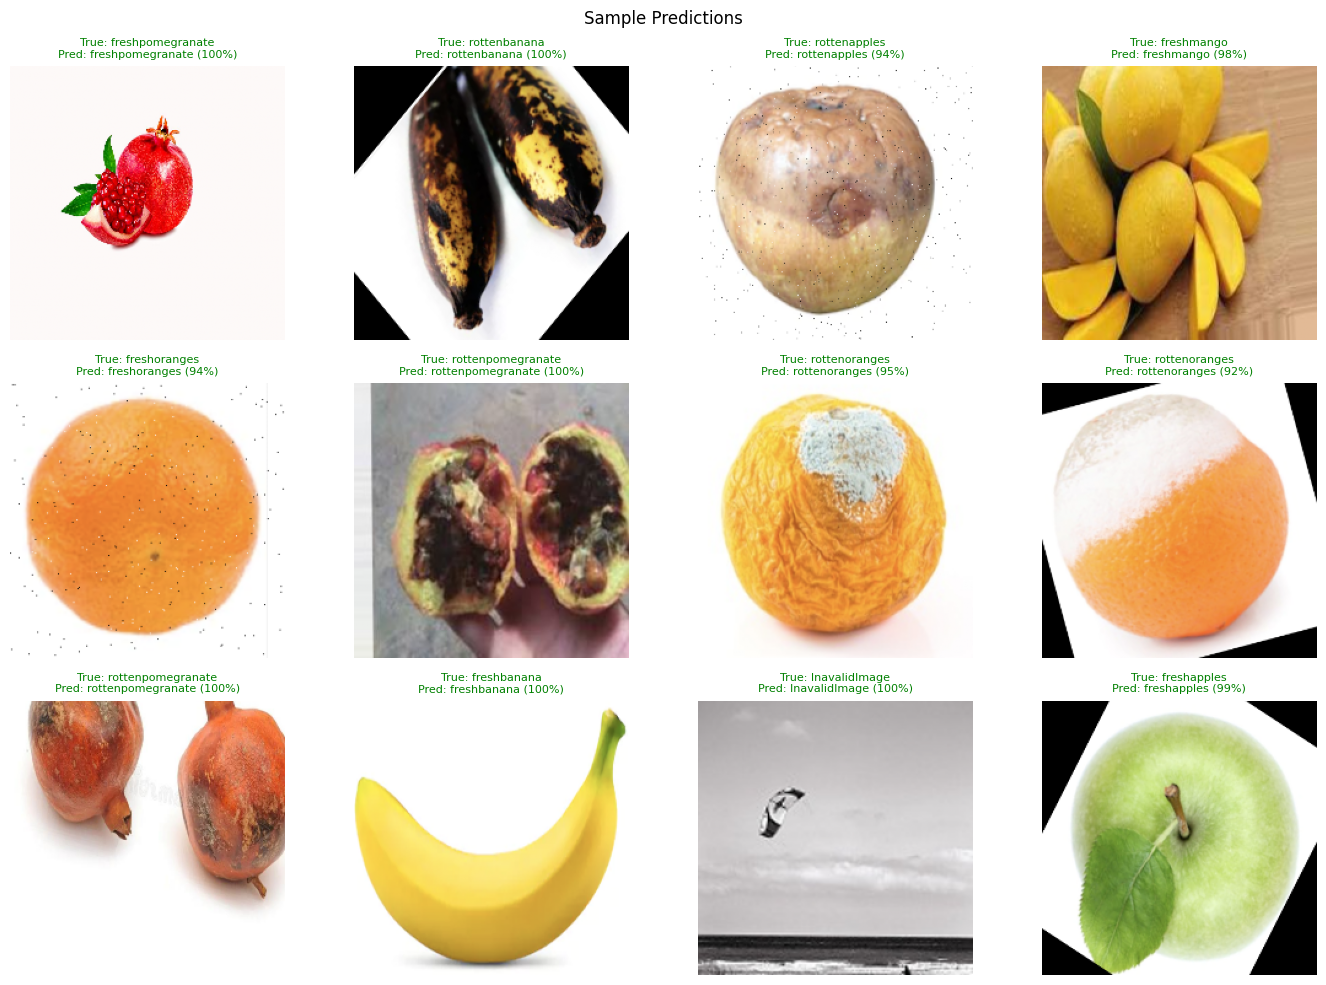

In [31]:
pred_all = model.predict(X_test, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
indices = np.random.randint(0, len(X_test), 12)

for i, ax in zip(indices, axes.flat):
    img = X_test[i]
    true_label = cate[Y_test[i]]
    pred_label = cate[np.argmax(pred_all[i])]
    confidence = np.max(pred_all[i]) * 100

    ax.imshow(img)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)", color=color, fontsize=8)

plt.suptitle('Sample Predictions', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# TESTING

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


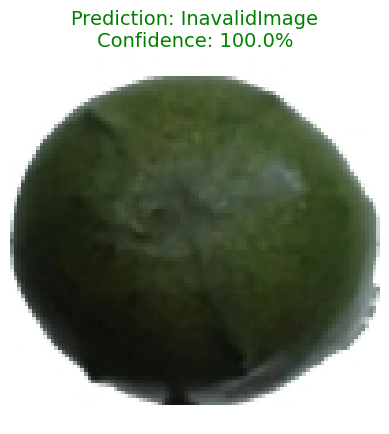

In [32]:
img_path = r"U:\Fruits_New\InavalidImage\r1_83_100.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))
img_normalized = img_resized / 255.0
img_input = np.expand_dims(img_normalized, axis=0)

pred_single = model.predict(img_input)[0]
pred_label = cate[np.argmax(pred_single)]
confidence = np.max(pred_single) * 100

# Show image with prediction
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Prediction: {pred_label}\nConfidence: {confidence:.1f}%", 
          fontsize=14, color='green')
plt.show()

In [33]:
from tensorflow.keras.models import load_model

model = load_model('food_freshness_or_rotten_model.keras')
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print("Model ready!")

Model ready!


In [35]:
import os
from tensorflow.keras.models import load_model

model = load_model('food_freshness_or_rotten_model.h5')
model.summary()

size_mb = os.path.getsize('food_freshness_or_rotten_model.h5') / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 13)                  │           1,677 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,818,191 (98.49 MB)

 Trainable params: 25,818,189 (98.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Model size: 295.52 MB


In [36]:
import tensorflow as tf
model = tf.keras.models.load_model('food_freshness_or_rotten_model.keras')
model.save('food_freshness_deploy.keras', include_optimizer=False)

In [41]:
import os
from tensorflow.keras.models import load_model

model = load_model('food_freshness_deploy.h5')
model.summary()

size_mb = os.path.getsize('food_freshness_deploy.h5') / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 13)                  │           1,677 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,818,189 (98.49 MB)

 Trainable params: 25,818,189 (98.49 MB)

 Non-trainable params: 0 (0.00 B)

Model size: 98.52 MB
